# Exploratory Data Analysis (EDA) - IEEE-CIS Fraud Detection

This notebook performs a systematic exploratory analysis on the IEEE-CIS Fraud Detection dataset to identify patterns, missingness, and relationships between features and the target variable (`isFraud`).


In [1]:
import sys
import os
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

train_tx_path = project_root / "data" / "raw" / "train_transaction.csv"
train_id_path = project_root / "data" / "raw" / "train_identity.csv"
test_tx_path = project_root / "data" / "raw" / "test_transaction.csv"
test_id_path = project_root / "data" / "raw" / "test_identity.csv"


## 1. Load and Merge Data

In [2]:
from src.features.load_data import load_and_merge

print("Loading training data...")
df_train = load_and_merge(train_tx_path, train_id_path)
print(f"Training shape: {df_train.shape}")

print("\nLoading test data...")
df_test = load_and_merge(test_tx_path, test_id_path)
print(f"Test shape: {df_test.shape}")


Loading training data...
Training shape: (590540, 435)

Loading test data...
Test shape: (506691, 434)


## 2. Basic Dataset Overview & Imbalance

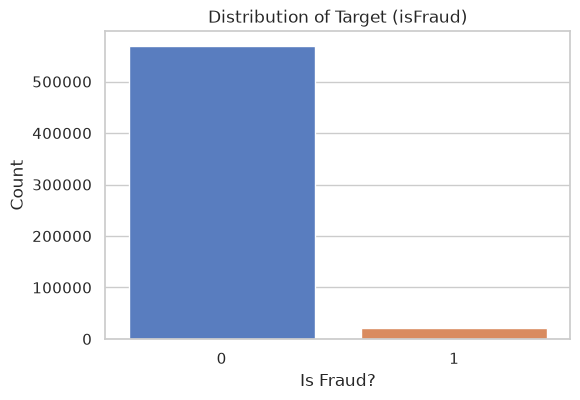

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="isFraud", data=df_train, hue="isFraud", legend=False, palette="muted")
plt.title("Distribution of Target (isFraud)")
plt.xlabel("Is Fraud?")
plt.ylabel("Count")
plt.show()


### 2.2 Missing Values Analysis

Missing values summary across all 400+ features:
count    435.000000
mean      44.970753
std       36.565030
min        0.000000
25%        0.265520
50%       47.293494
75%       77.913435
max       99.196159
dtype: float64


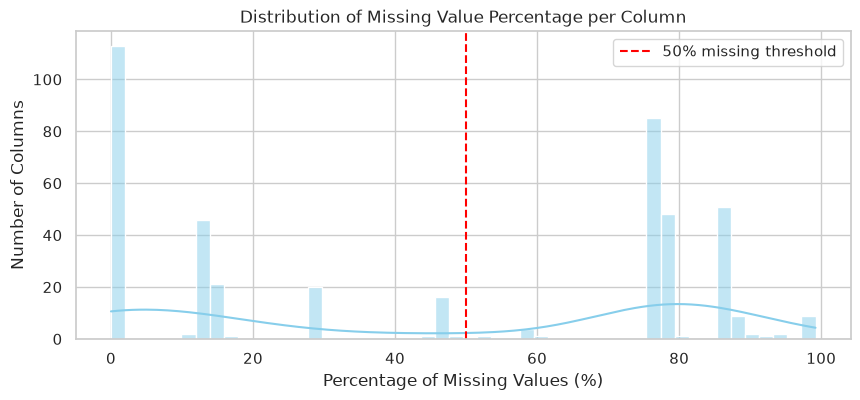

Number of columns with >50% missing values: 214 / 435


In [4]:
missing_pcts = df_train.isnull().mean() * 100
missing_summary = missing_pcts.describe()

print("Missing values summary across all 400+ features:")
print(missing_summary)

plt.figure(figsize=(10, 4))
sns.histplot(missing_pcts, bins=50, kde=True, color="skyblue")
plt.title("Distribution of Missing Value Percentage per Column")
plt.xlabel("Percentage of Missing Values (%)")
plt.ylabel("Number of Columns")
plt.axvline(50, color="red", linestyle="--", label="50% missing threshold")
plt.legend()
plt.show()

cols_over_50 = missing_pcts[missing_pcts > 50].index
print(f"Number of columns with >50% missing values: {len(cols_over_50)} / {df_train.shape[1]}")


## 3. Temporal Analysis (`TransactionDT`)

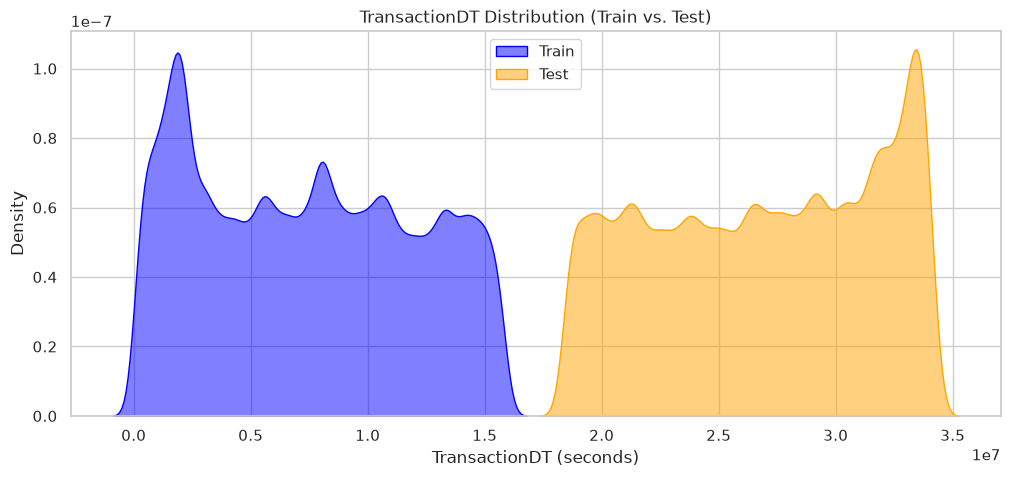

Train time range: 86400 to 15811131 (span: 182.00 days)
Test time range:  18403224 to 34214345 (span: 183.00 days)
Overlap between train and test: False


In [5]:
plt.figure(figsize=(12, 5))
sns.kdeplot(df_train["TransactionDT"], label="Train", fill=True, alpha=0.5, color="blue")
sns.kdeplot(df_test["TransactionDT"], label="Test", fill=True, alpha=0.5, color="orange")
plt.title("TransactionDT Distribution (Train vs. Test)")
plt.xlabel("TransactionDT (seconds)")
plt.ylabel("Density")
plt.legend()
plt.show()

train_min, train_max = df_train["TransactionDT"].min(), df_train["TransactionDT"].max()
test_min, test_max = df_test["TransactionDT"].min(), df_test["TransactionDT"].max()

print(f"Train time range: {train_min} to {train_max} (span: {(train_max - train_min)/(24*3600):.2f} days)")
print(f"Test time range:  {test_min} to {test_max} (span: {(test_max - test_min)/(24*3600):.2f} days)")
print(f"Overlap between train and test: {not (train_max < test_min or test_max < train_min)}")


### 3.2 Time-of-Day Cyclical Pattern

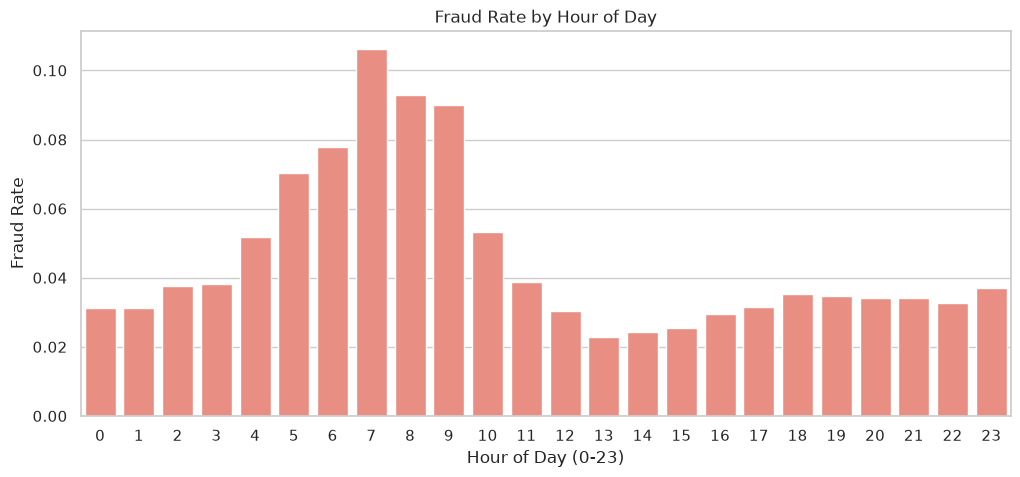

In [6]:
df_train["hour"] = (df_train["TransactionDT"] // 3600) % 24

plt.figure(figsize=(12, 5))
sns.barplot(x="hour", y="isFraud", data=df_train, errorbar=None, color="salmon")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Fraud Rate")
plt.show()


## 4. Transaction Amount Analysis (`TransactionAmt`)

TransactionAmt descriptive stats for Non-Fraud:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

TransactionAmt descriptive stats for Fraud:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


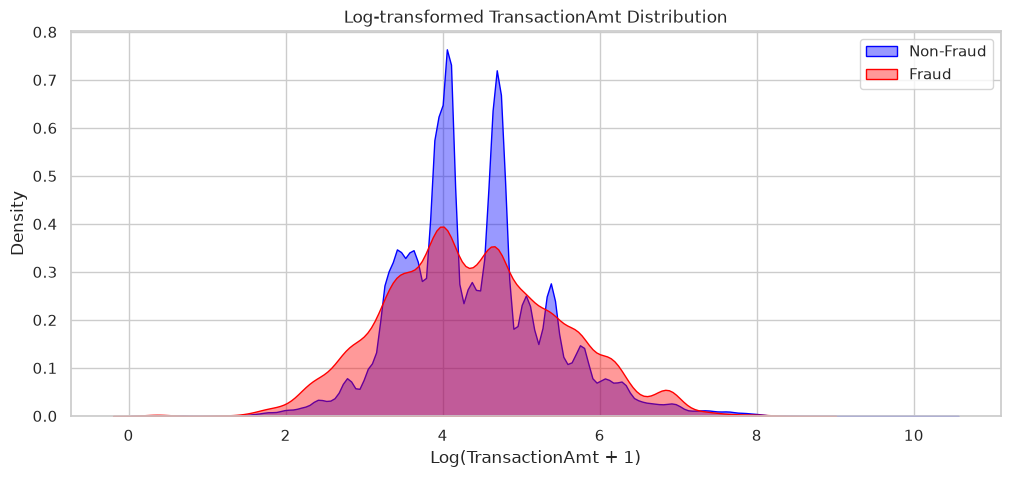

In [7]:
print("TransactionAmt descriptive stats for Non-Fraud:")
print(df_train[df_train["isFraud"] == 0]["TransactionAmt"].describe())
print("\nTransactionAmt descriptive stats for Fraud:")
print(df_train[df_train["isFraud"] == 1]["TransactionAmt"].describe())

df_train["log_TransactionAmt"] = np.log1p(df_train["TransactionAmt"])

plt.figure(figsize=(12, 5))
sns.kdeplot(df_train[df_train["isFraud"] == 0]["log_TransactionAmt"], label="Non-Fraud", fill=True, alpha=0.4, color="blue")
sns.kdeplot(df_train[df_train["isFraud"] == 1]["log_TransactionAmt"], label="Fraud", fill=True, alpha=0.4, color="red")
plt.title("Log-transformed TransactionAmt Distribution")
plt.xlabel("Log(TransactionAmt + 1)")
plt.ylabel("Density")
plt.legend()
plt.show()


## 5. Categorical Feature Analysis

### 5.1 ProductCD

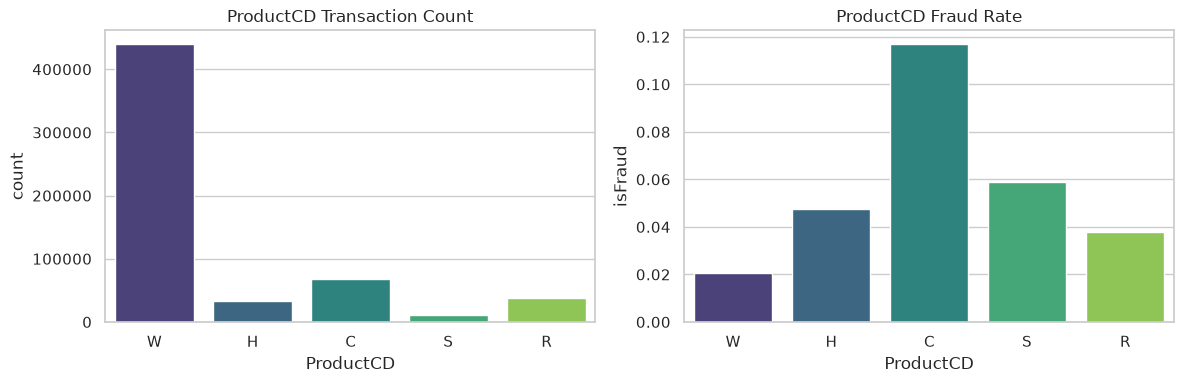

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(x="ProductCD", data=df_train, palette="viridis", hue="ProductCD", legend=False)
plt.title("ProductCD Transaction Count")

plt.subplot(1, 2, 2)
sns.barplot(x="ProductCD", y="isFraud", data=df_train, errorbar=None, palette="viridis", hue="ProductCD", legend=False)
plt.title("ProductCD Fraud Rate")

plt.tight_layout()
plt.show()


### 5.2 Card Features: card4 and card6


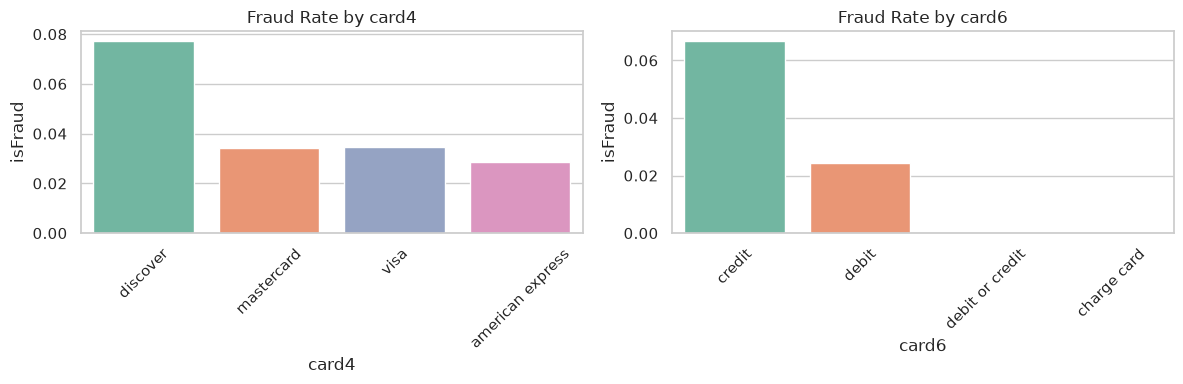

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.barplot(x="card4", y="isFraud", data=df_train, errorbar=None, hue="card4", legend=False, palette="Set2")
plt.title("Fraud Rate by card4")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x="card6", y="isFraud", data=df_train, errorbar=None, hue="card6", legend=False, palette="Set2")
plt.title("Fraud Rate by card6")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### 5.3 Email Domains (`P_emaildomain`)

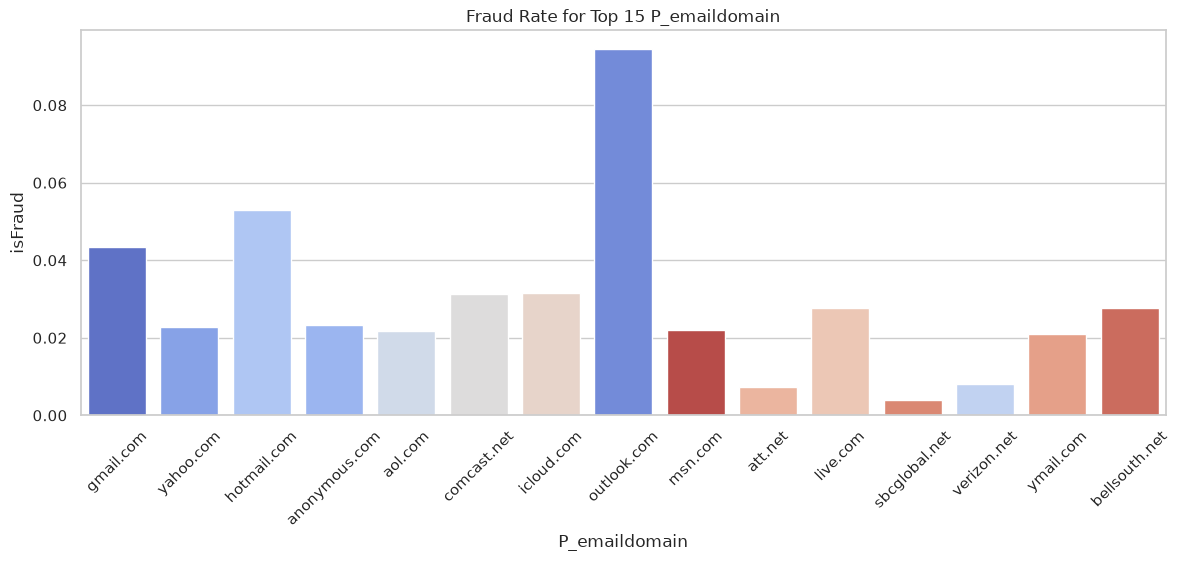

In [10]:
top_domains = df_train["P_emaildomain"].value_counts().head(15).index
df_top_email = df_train[df_train["P_emaildomain"].isin(top_domains)]

plt.figure(figsize=(14, 5))
sns.barplot(x="P_emaildomain", y="isFraud", data=df_top_email, order=top_domains, errorbar=None, palette="coolwarm", hue="P_emaildomain", legend=False)
plt.title("Fraud Rate for Top 15 P_emaildomain")
plt.xticks(rotation=45)
plt.show()


## 6. Identity Data and Device Type

### 6.1 'has_identity' Feature

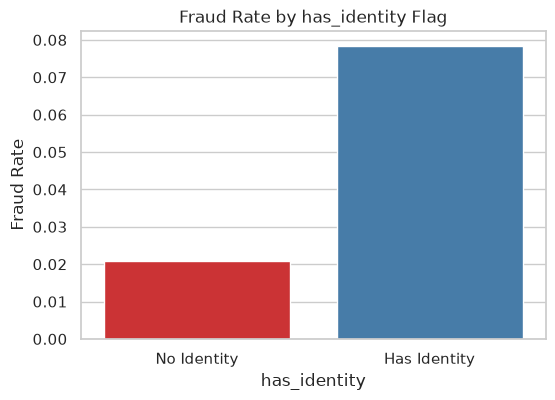

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(x="has_identity", y="isFraud", data=df_train, errorbar=None, palette="Set1", hue="has_identity", legend=False)
plt.title("Fraud Rate by has_identity Flag")
plt.xticks([0, 1], ["No Identity", "Has Identity"])
plt.ylabel("Fraud Rate")
plt.show()


### 6.2 Device Type (`DeviceType`)

            Transaction Count  Fraud Rate (%)
DeviceType                                   
desktop                 85165        6.521458
mobile                  55645       10.166232
NaN                    449730        2.101705


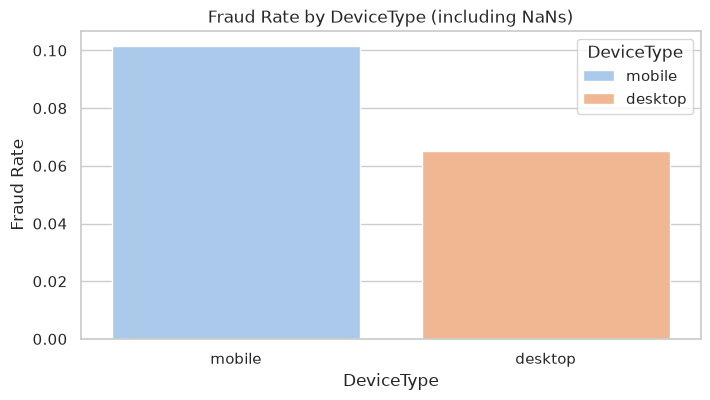

In [12]:
device_stats = df_train.groupby("DeviceType", dropna=False)["isFraud"].agg(["count", "mean"])
device_stats["mean"] = device_stats["mean"] * 100
device_stats.columns = ["Transaction Count", "Fraud Rate (%)"]
print(device_stats)

plt.figure(figsize=(8, 4))
sns.barplot(x="DeviceType", y="isFraud", data=df_train, errorbar=None, hue="DeviceType", palette="pastel")
plt.title("Fraud Rate by DeviceType (including NaNs)")
plt.ylabel("Fraud Rate")
plt.show()


## 7. Statistical Association & Correlation Analysis

### 7.1 Collinearity of Selected Features


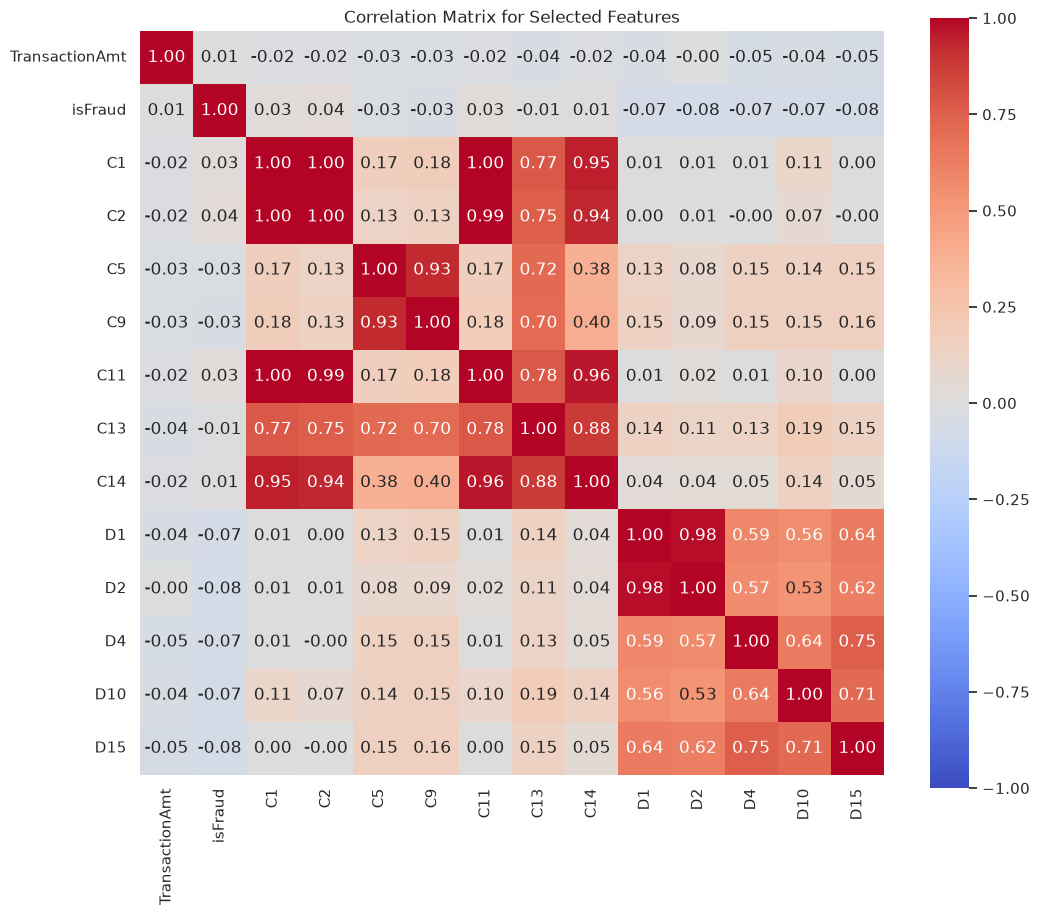

In [13]:
c_cols = [f"C{i}" for i in [1, 2, 5, 9, 11, 13, 14]]
d_cols = [f"D{i}" for i in [1, 2, 4, 10, 15]]
corr_cols = ["TransactionAmt", "isFraud"] + c_cols + d_cols

corr_cols = [c for c in corr_cols if c in df_train.columns]

corr_matrix = df_train[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix for Selected Features")
plt.show()


### 7.2 Numerical Features Correlation with `isFraud`

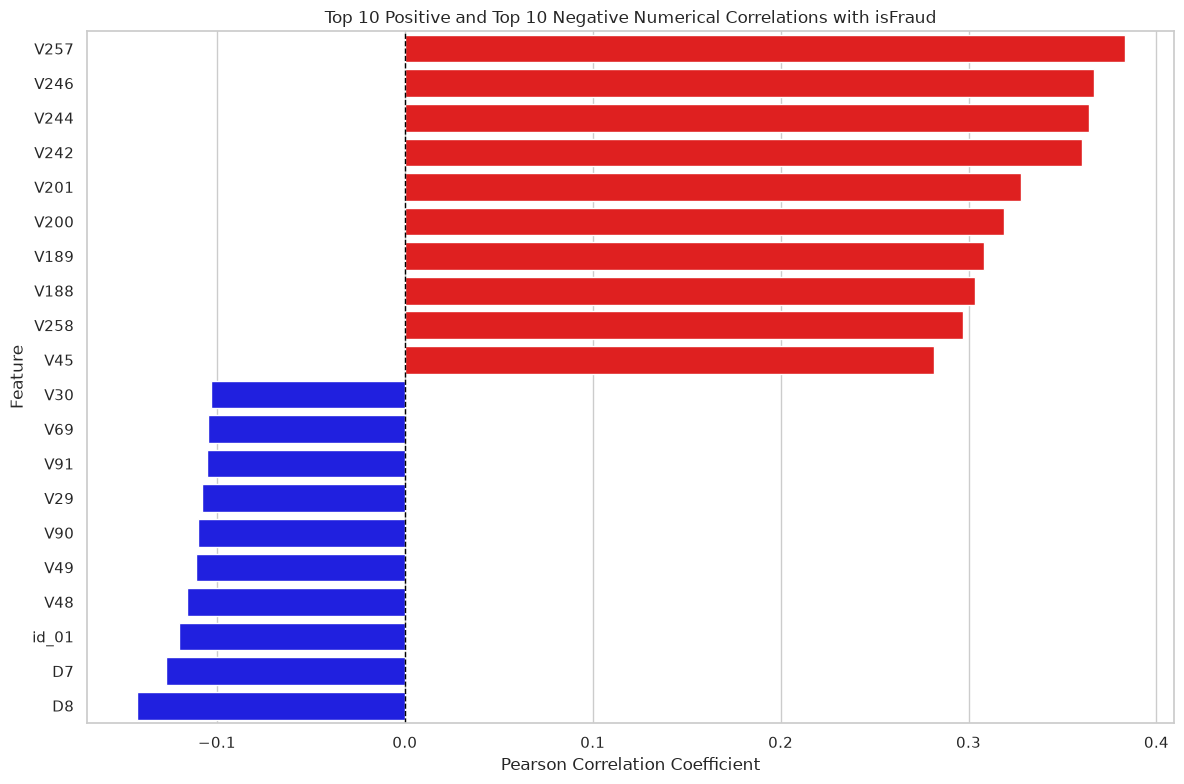

In [14]:
numerical_cols = df_train.select_dtypes(include='number').columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['TransactionID', 'isFraud']]

correlations = df_train[numerical_cols].corrwith(df_train['isFraud'])
corr_df = pd.DataFrame({
    'feature': correlations.index,
    'correlation': correlations.values,
    'abs_correlation': correlations.abs().values
}).sort_values('abs_correlation', ascending=False)

top_pos = corr_df[corr_df['correlation'] > 0].sort_values('correlation', ascending=False).head(10)
top_neg = corr_df[corr_df['correlation'] < 0].sort_values('correlation', ascending=True).head(10)
top_combined = pd.concat([top_pos, top_neg]).sort_values('correlation', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['red' if val > 0 else 'blue' for val in top_combined['correlation']]
sns.barplot(x='correlation', y='feature', data=top_combined, palette=colors, hue='feature', legend=False)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Top 10 Positive and Top 10 Negative Numerical Correlations with isFraud")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 7.3 Categorical Features Association with `isFraud`

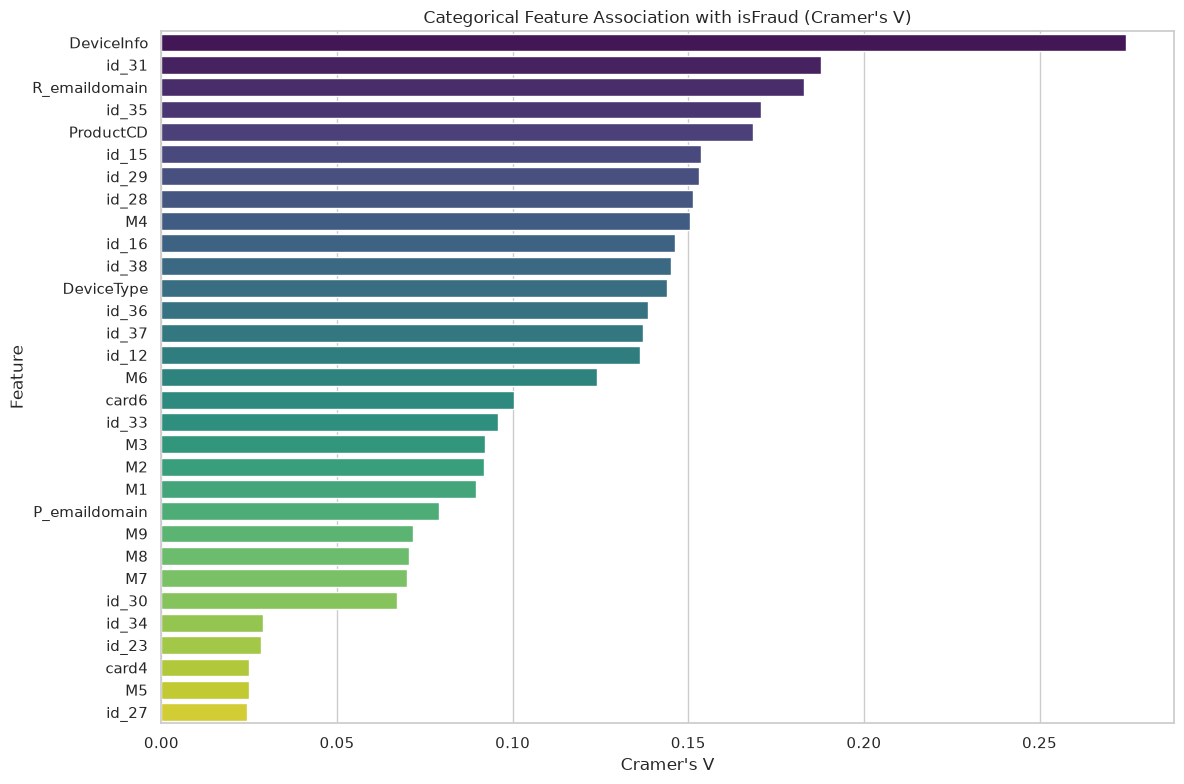

In [15]:
def calculate_cramers_v(df, cat_col, target_col='isFraud'):
    s_feat = df[cat_col].astype(str).fillna('Missing')
    s_target = df[target_col]
    
    observed = pd.crosstab(s_feat, s_target)
    
    row_sums = observed.sum(axis=1).values
    col_sums = observed.sum(axis=0).values
    n = observed.values.sum()
    
    if n == 0 or len(row_sums) <= 1 or len(col_sums) <= 1:
        return 0.0, 0.0
        
    expected = np.outer(row_sums, col_sums) / n
    expected = np.where(expected == 0, 1e-9, expected)
    
    chi2 = np.sum((observed.values - expected) ** 2 / expected)
    
    v = np.sqrt(chi2 / n)
    
    return chi2, v

categorical_cols = df_train.select_dtypes(exclude='number').columns.tolist()
assoc_results = []

for col in categorical_cols:
    chi2, v = calculate_cramers_v(df_train, col)
    assoc_results.append({
        'feature': col,
        'chi2_statistic': chi2,
        'cramers_v': v
    })

assoc_df = pd.DataFrame(assoc_results).sort_values('cramers_v', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='cramers_v', y='feature', data=assoc_df, palette='viridis', hue='feature', legend=False)
plt.title("Categorical Feature Association with isFraud (Cramer's V)")
plt.xlabel("Cramer's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()